# **Fichier d'analyse des résulats**

## Chargement librairies etc

In [113]:
import pandas as pd
import json

import matplotlib.pyplot as plt
from matplotlib import font_manager
import os


In [114]:
# Paramètres pour les graphiques
font_dir = "assets"

for file in os.listdir(font_dir):
    if file.endswith(".ttf"):
        font_manager.fontManager.addfont(os.path.join(font_dir, file))

plt.rcParams["font.family"] = "Marianne"
plt.rcParams.update({
    "font.family": "Marianne",

    "axes.titlesize": 16,
    "axes.titleweight": "bold",

    "figure.titlesize": 18,
    "figure.titleweight": "bold",

    "axes.labelsize": 12,
    "axes.labelweight": "regular",

    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "legend.fontsize": 10,
})

# Colors and styles for plotting
palette = {
    "Solar":      "#d66b0d",
    "Hydro":        "#2672b0",
    "Onshore":      "#72cbb7",
    "Offshore":     "#4d8377",
    "H2_CCG":       "#e4a701",
    "H2_TAC":       "#f0c040",
    "STEP_charge":  "#7a1616",
    "Fond":         "#ffffff",
    "STEP_discharge": "#ff0000",
    "Battery_charge": "#4B1063",
    "Battery_discharge": "#d126c9",
    "Battery" : "#8226A7",
    "hy_th_fatal": "#0C2DEB",
    "Electrolyse": "#e27c9a",
}

# Colonnes production (positives)
prod_cols = [
    'hy_th_fatal','H2_CCG','H2_TAC','Hydro','Onshore','Offshore',
        'STEP_discharge','Battery_discharge','Solar','Electrolyse'
]

# Colonnes charge
charge_cols = [
    'STEP_charge','Battery_charge'
]

## __0. Lecture des données__

In [115]:
# Config de lecture des données
WEEK_TO_PLOT = 0  # semaine de départ
TWO_WEEKS = False   # True pour 2 semaines, False pour 1 semaine

id = "2DC79E79"
df_global = pd.read_csv(f"results/annual_master/results_{id}.csv", sep=';')

parc = json.load(open(f"results/annual_master/parc_annuel_{id}.json", "r"))
evolution_parc = json.load(open(f"results/annual_master/evolution_parc_{id}.json", "r"))

df_global.drop(columns=['t'], inplace=True)

# Suppression des lignes sans production ni charge
df_global.drop(df_global[df_global[prod_cols + charge_cols].sum(axis=1) == 0].index, inplace=True)

# Calcul du nombre de semaines à sélectionner
num_weeks_to_plot = 2 if TWO_WEEKS else 1

# Sélection des lignes correspondantes
start_idx = WEEK_TO_PLOT * 7 * 24
end_idx = (WEEK_TO_PLOT + num_weeks_to_plot) * 7 * 24
df = df_global.iloc[start_idx:end_idx].copy()

## **1. EOD : vue générale**

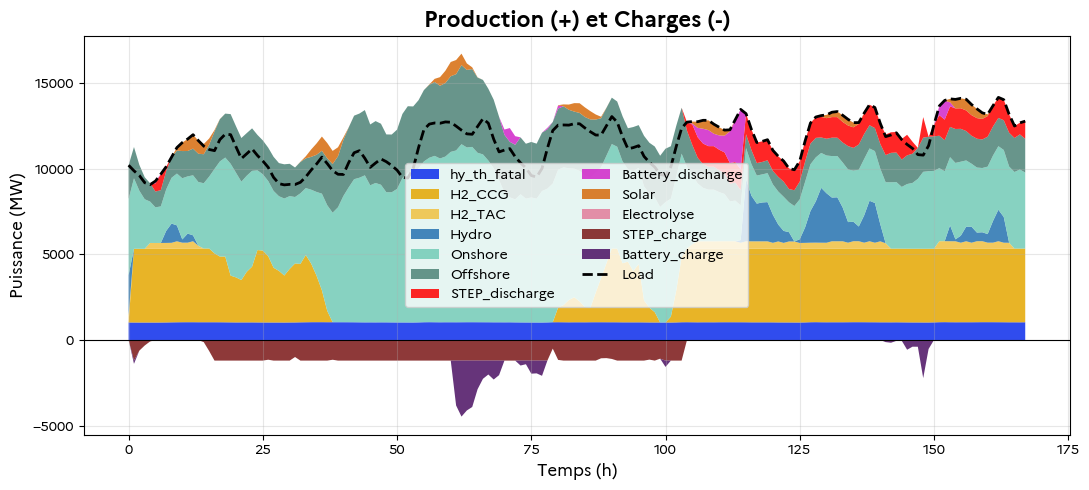

In [116]:
plt.figure(figsize=(11,5))

# --- STACK POSITIF ---
plt.stackplot(
    df.index,
    [df[c] for c in prod_cols],
    colors=[palette[c] for c in prod_cols],
    labels=prod_cols,
    alpha=0.85
)

# --- STACK NEGATIF ---
plt.stackplot(
    df.index,
    [-df[c] for c in charge_cols],   # ⚠️ on met en négatif
    colors=[palette[c] for c in charge_cols],
    labels=charge_cols,
    alpha=0.85
)

# Ligne zéro
plt.axhline(0, color="black", linewidth=0.8)

# Load
plt.plot(df.index, df['Load'], color="black", linestyle='--', linewidth=2, label="Load")

plt.title("Production (+) et Charges (-)")
plt.xlabel("Temps (h)")
plt.ylabel("Puissance (MW)")
plt.legend(ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

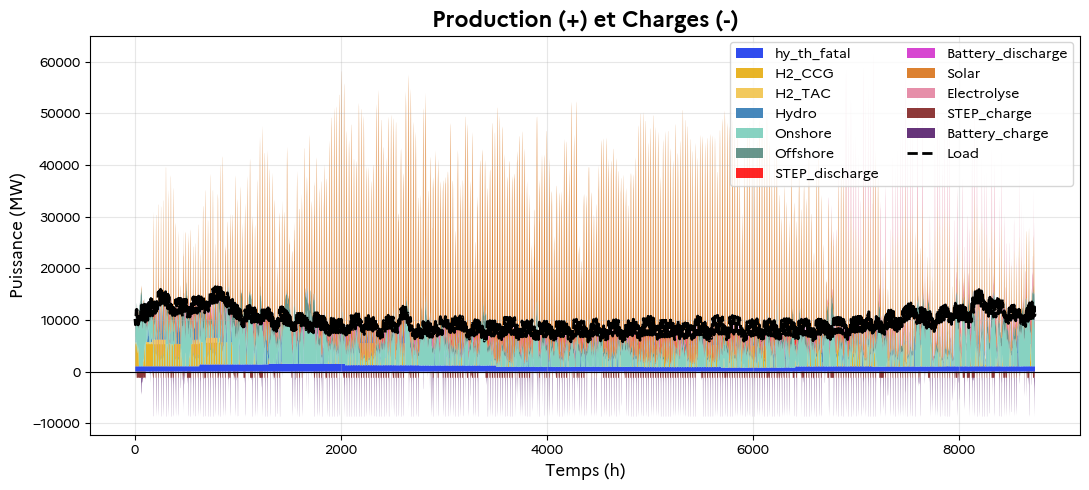

In [117]:
plt.figure(figsize=(11,5))

# --- STACK POSITIF ---
plt.stackplot(
    df_global.index,
    [df_global[c] for c in prod_cols],
    colors=[palette[c] for c in prod_cols],
    labels=prod_cols,
    alpha=0.85
)

# --- STACK NEGATIF ---
plt.stackplot(
    df_global.index,
    [-df_global[c] for c in charge_cols],   # ⚠️ on met en négatif
    colors=[palette[c] for c in charge_cols],
    labels=charge_cols,
    alpha=0.85
)

# Ligne zéro
plt.axhline(0, color="black", linewidth=0.8)

# Load
plt.plot(df_global.index, df_global['Load'], color="black", linestyle='--', linewidth=2, label="Load")

plt.title("Production (+) et Charges (-)")
plt.xlabel("Temps (h)")
plt.ylabel("Puissance (MW)")
plt.legend(ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### **1.2 Semaines sous tension**

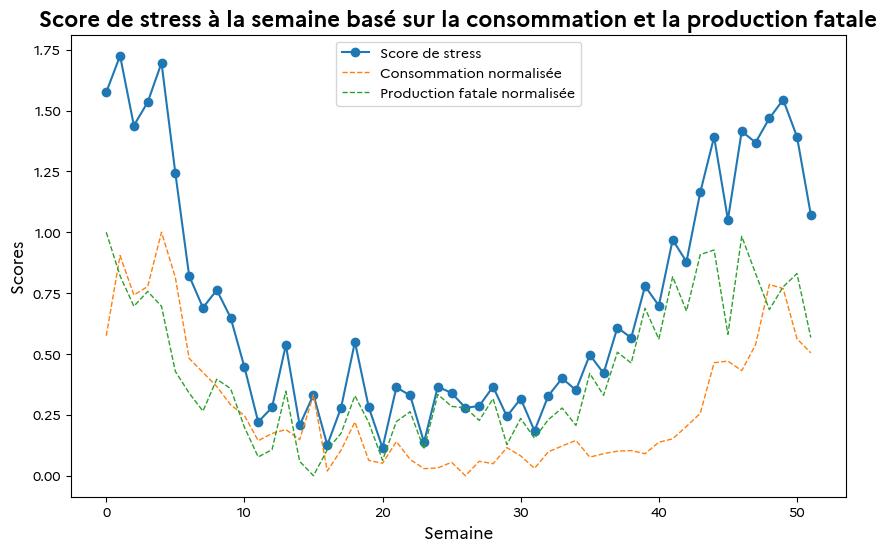

Top 5 semaines les plus stressantes :
week
1     1.724999
4     1.695588
0     1.574827
49    1.544525
3     1.534226
dtype: float64


In [118]:
df_global['week'] = (df_global.index // 24) // 7  # semaines 0 à 51
weekly_load = df_global.groupby('week')['Load'].sum()  # ou sum() si tu préfères la conso totale

weekly_fatal = df_global.groupby('week')[['Solar','Onshore','Offshore', 'hy_th_fatal']].sum().sum(axis=1)
# axis=1 pour sommer les types d'EnR par semaine

# Normalisation
load_norm = (weekly_load - weekly_load.min()) / (weekly_load.max() - weekly_load.min())
weekly_fatal_norm = 1 - ((weekly_fatal - weekly_fatal.min()) / (weekly_fatal.max() - weekly_fatal.min()))  # faible facteur = haute tension

stress_score = load_norm + weekly_fatal_norm

plt.figure(figsize=(10,6))
plt.plot(stress_score.index, stress_score.values, marker='o', label="Score de stress")
plt.plot(stress_score.index, load_norm.values, marker='', linestyle='--', linewidth=1, label="Consommation normalisée")
plt.plot(stress_score.index, weekly_fatal_norm.values, marker='', linestyle='--', linewidth=1, label="Production fatale normalisée")
plt.xlabel("Semaine")
plt.ylabel("Scores")
plt.title("Score de stress à la semaine basé sur la consommation et la production fatale")
plt.legend()
plt.show()


top5 = stress_score.sort_values(ascending=False).head(5)

print("Top 5 semaines les plus stressantes :")
print(top5)

# Semaine la plus et la moins stressante
week_max = stress_score.idxmax()
week_min = stress_score.idxmin()



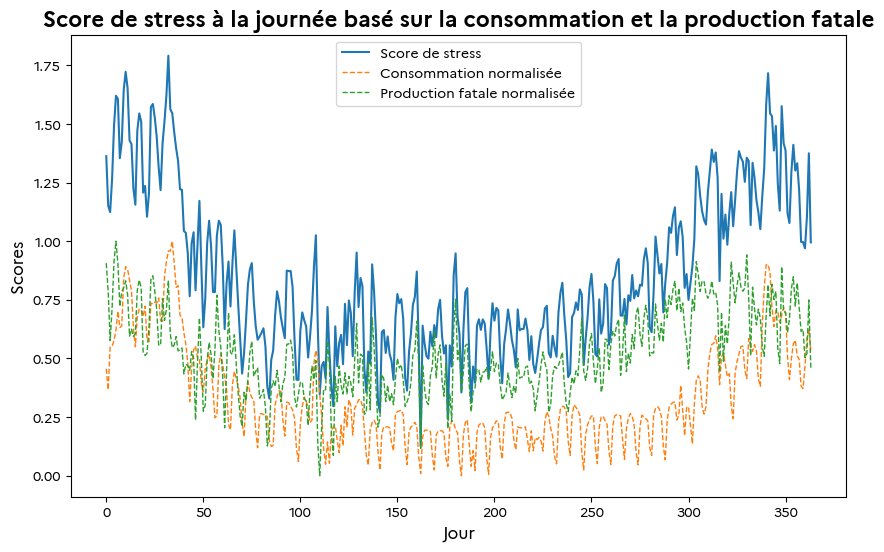

Top 5 jours les plus stressants:
day
32     1.791107
10     1.722570
341    1.716615
11     1.652143
9      1.645530
dtype: float64


In [119]:
df_global['day'] = (df_global.index // 24)  
daily_load = df_global.groupby('day')['Load'].sum()  # ou sum() si tu préfères la conso totale

daily_load = df_global.groupby('day')['Load'].sum()  # ou sum() si tu préfères la conso totale

daily_fatal = df_global.groupby('day')[['Solar','Onshore','Offshore', 'hy_th_fatal']].sum().sum(axis=1)
# axis=1 pour sommer les types d'EnR par semaine

# Normalisation
load_norm = (daily_load - daily_load.min()) / (daily_load.max() - daily_load.min())
daily_fatal_norm = 1 - ((daily_fatal - daily_fatal.min()) / (daily_fatal.max() - daily_fatal.min()))  # faible facteur = haute tension

stress_score = load_norm + daily_fatal_norm

plt.figure(figsize=(10,6))
plt.plot(stress_score.index, stress_score.values, marker='', label="Score de stress")
plt.plot(stress_score.index, load_norm.values, marker='', linestyle='--', linewidth=1, label="Consommation normalisée")
plt.plot(stress_score.index, daily_fatal_norm.values, marker='', linestyle='--', linewidth=1, label="Production fatale normalisée")
plt.xlabel("Jour")
plt.ylabel("Scores")
plt.title("Score de stress à la journée basé sur la consommation et la production fatale")
plt.legend()
plt.show()


top5 = stress_score.sort_values(ascending=False).head(5)

print("Top 5 jours les plus stressants:")
print(top5)

**EOD de la semaine la plus tendue vs la moins tendue**

Semaine la plus tendue : 1
Semaine la moins tendue : 20


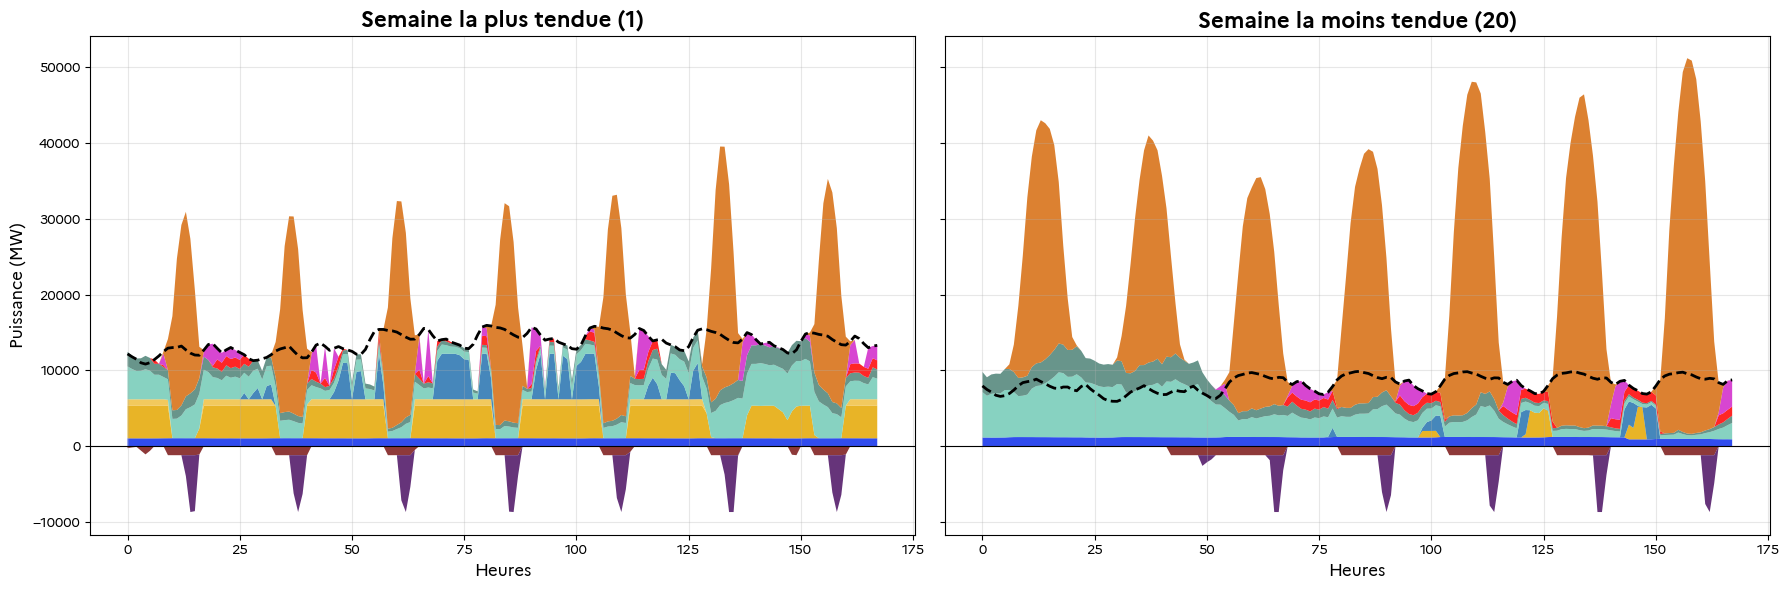

In [120]:
print("Semaine la plus tendue :", week_max)
print("Semaine la moins tendue :", week_min)

# Extraction des semaines
df_max = df_global[df_global['week'] == week_max].copy()
df_min = df_global[df_global['week'] == week_min].copy()

# Reset index pour affichage propre
df_max = df_max.reset_index(drop=True)
df_min = df_min.reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(18,6), sharey=True)

for ax, df_week, title in zip(
    axes,
    [df_max, df_min],
    [f"Semaine la plus tendue ({week_max})",
     f"Semaine la moins tendue ({week_min})"]
):

    # --- STACK POSITIF ---
    ax.stackplot(
        df_week.index,
        [df_week[c] for c in prod_cols],
        colors=[palette[c] for c in prod_cols],
        alpha=0.85
    )

    # --- STACK NEGATIF ---
    ax.stackplot(
        df_week.index,
        [-df_week[c] for c in charge_cols],
        colors=[palette[c] for c in charge_cols],
        alpha=0.85
    )

    ax.axhline(0, color="black", linewidth=0.8)
    ax.plot(df_week.index, df_week['Load'],
            color="black", linestyle='--', linewidth=2)

    ax.set_title(title)
    ax.set_xlabel("Heures")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Puissance (MW)")
plt.tight_layout()
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.show()

## **2. Capacités installées**

In [ ]:
import json
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mtick
import os

data = parc["capacites_MW"].copy()

# ------------------------
# AJOUT H2 CCG + TAC
# ------------------------
if "H2" in parc:

    Pmax_CCG_unite = 430  # MW par unité CCG
    Pmax_TAC_unite = 85   # MW par unité TAC

    nb_CCG = parc["H2"]["CCG"]["nombre_installees"]
    nb_TAC = parc["H2"]["TAC"]["nombre_installees"]

    data["CCG_H2"] = nb_CCG * Pmax_CCG_unite
    data["TAC_H2"] = nb_TAC * Pmax_TAC_unite

# ------------------------
# Icônes associées
# ------------------------
icons = {
    "onshore": "assets/icons/eolien.png",
    "offshore": "assets/icons/eolien_offshore.png",
    "solar": "assets/icons/solaire.png",
    "battery": "assets/icons/batterie.png",
    "CCG_H2": "assets/icons/h2.png",
    "TAC_H2": "assets/icons/h2.png",
}

# ------------------------
# Fonction icône
# ------------------------
def add_icon(ax, x, y, icon_path, zoom=0.08):
    if not os.path.exists(icon_path):
        return
    img = plt.imread(icon_path)
    ab = AnnotationBbox(
        OffsetImage(img, zoom=zoom),
        (x, y),
        frameon=False,
        box_alignment=(0, 0.5)
    )
    ax.add_artist(ab)

# ------------------------
# Préparation données
# ------------------------
labels = list(data.keys())
values = list(data.values())



labels, values = zip(*sorted(zip(labels, values), key=lambda t: t[1]))

# ------------------------
# Plot
# ------------------------
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(labels, values)

ax.set_title("Capacités installées optimales", fontweight="bold")
ax.set_xlabel("Puissance installée (MW)")
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

# Icônes
xmin, xmax = ax.get_xlim()
icon_x = xmin + (xmax - xmin) * 0.02

for y, label in enumerate(labels):
    add_icon(ax, icon_x, y, icons.get(label, ""), zoom=0.07)

ax.margins(x=0.15)
ax.grid(axis="x", alpha=0.2)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

## **3. Capacités de stockage**

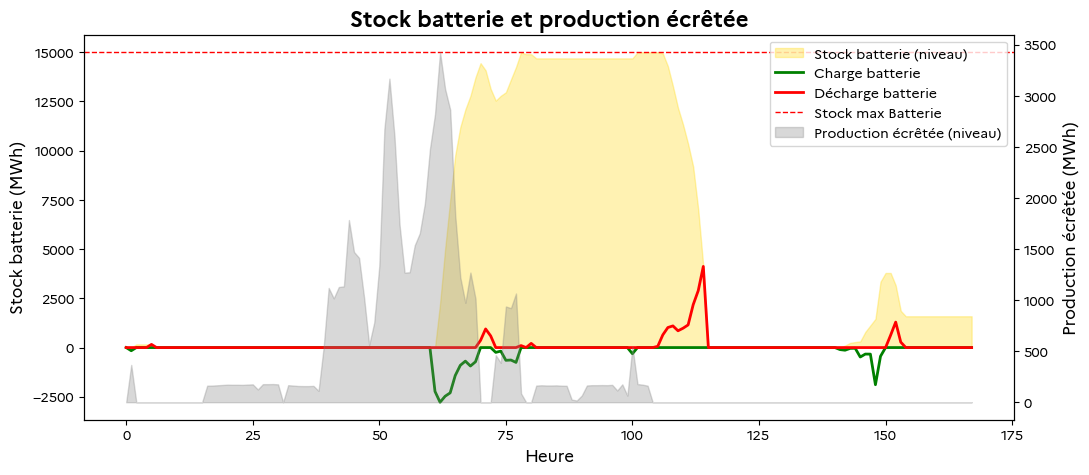

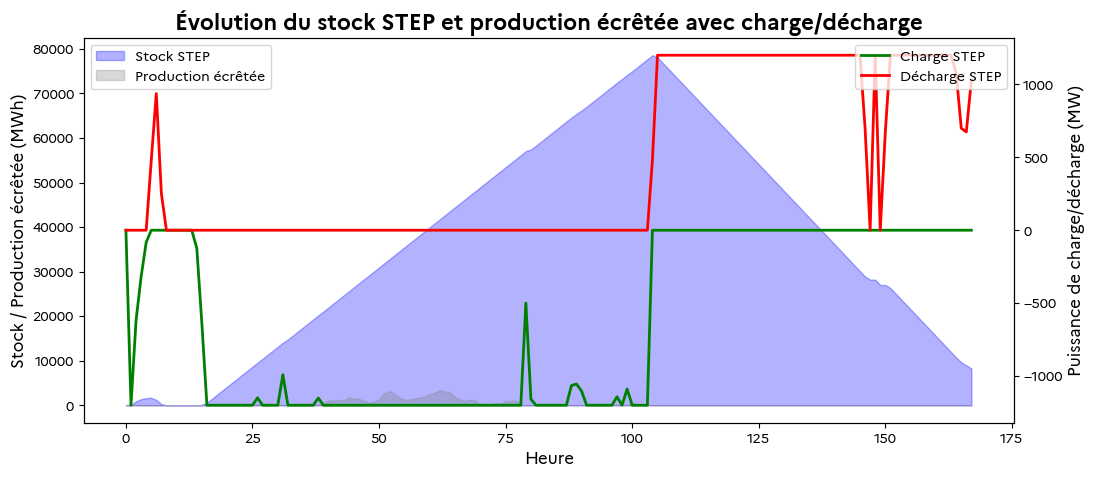

In [ ]:
import numpy as np

CapaBattery = parc["capacites_MW"]["battery"]
d_battery = 2   # heures
stock_max_battery = CapaBattery * d_battery
rbattery = 0.85

# --- Calcul de la production totale ---
df["Prod_totale"] = df["H2_CCG"] + df["H2_TAC"] + df["Hydro"] + df["Solar"] + df["Onshore"] + df["Offshore"]

# --- Production écrêtée avant utilisation des stocks ---
df["Ecret"] = df["Prod_totale"] - df["Load"]
df["Ecret"] = df["Ecret"].clip(lower=0)  # pas de valeurs négatives

# --- Axe temps ---
time = df.index

# --- Plot Stock Batterie ---

fig, ax1 = plt.subplots(figsize=(12,5))

# Axe principal : stock batterie
ax1.fill_between(time, 0, df["Battery_stock"], color='gold', alpha=0.3, label="Stock batterie (niveau)")

ax1.plot(time, -df["Battery_charge"]*rbattery, linewidth=2, color='green', label="Charge batterie")
ax1.plot(time, df["Battery_discharge"]/rbattery, linewidth=2, color='red', label="Décharge batterie")
ax1.axhline(y=stock_max_battery, linestyle="--", linewidth=1, color="red", label="Stock max Batterie")
ax1.set_xlabel("Heure")
ax1.set_ylabel("Stock batterie (MWh)")

# Axe secondaire : production écrêtée
ax2 = ax1.twinx()
# ax2.plot(time, df["Ecret"], linestyle="--", linewidth=2,color="gray", label="Production écrêtée")
ax2.fill_between(time, 0, df["Ecret"], color='gray', alpha=0.3, label="Production écrêtée (niveau)")
ax2.set_ylabel("Production écrêtée (MWh)")

# Légende combinée
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.title("Stock batterie et production écrêtée")
plt.show()

# --- Plot Stock STEP ---
# On peut calculer stock max STEP si on a Pmax_STEP et durée max 24*7h
#stock_max_STEP = ?


fig, ax1 = plt.subplots(figsize=(12,5))

# Axe principal : Stock STEP et production écrêtée
ax1.fill_between(time, 0, df["STEP_stock"], color='blue', alpha=0.3, label="Stock STEP")
ax1.fill_between(time, 0, df["Ecret"], color='gray', alpha=0.3, label="Production écrêtée")
ax1.set_xlabel("Heure")
ax1.set_ylabel("Stock / Production écrêtée (MWh)")
ax1.legend(loc='upper left')

# Axe secondaire : Charge et décharge
ax2 = ax1.twinx()
ax2.plot(time, -df["STEP_charge"], color='green', linewidth=2, label="Charge STEP")
ax2.plot(time, df["STEP_discharge"], color='red', linewidth=2, label="Décharge STEP")
ax2.set_ylabel("Puissance de charge/décharge (MW)")
ax2.legend(loc='upper right')

plt.title("Évolution du stock STEP et production écrêtée avec charge/décharge")
plt.show()



**Test : charge et décharge simultanée**

In [ ]:
#Batteries

# Test si charge et décharge sont simultanées
simultaneous = np.logical_and(df_global["Battery_charge"] > 0, df_global["Battery_discharge"] > 0)

if simultaneous.any():
    print("⚠️ Attention : charge et décharge simultanées détectées !")
    # Afficher les indices où cela se produit
    print("Heures concernées :", np.where(simultaneous)[0])
else:
    print("✅ Pas de charge/décharge simultanée détectée")

✅ Pas de charge/décharge simultanée détectée


In [ ]:
#STEP

# Test si charge et décharge sont simultanées
simultaneous = np.logical_and(df_global["STEP_charge"] > 0, df_global["STEP_discharge"] > 0)

if simultaneous.any():
    print("⚠️ Attention : charge et décharge simultanées détectées !")
    # Afficher les indices où cela se produit
    print("Heures concernées :", np.where(simultaneous)[0])
else:
    print("✅ Pas de charge/décharge simultanée détectée")

✅ Pas de charge/décharge simultanée détectée


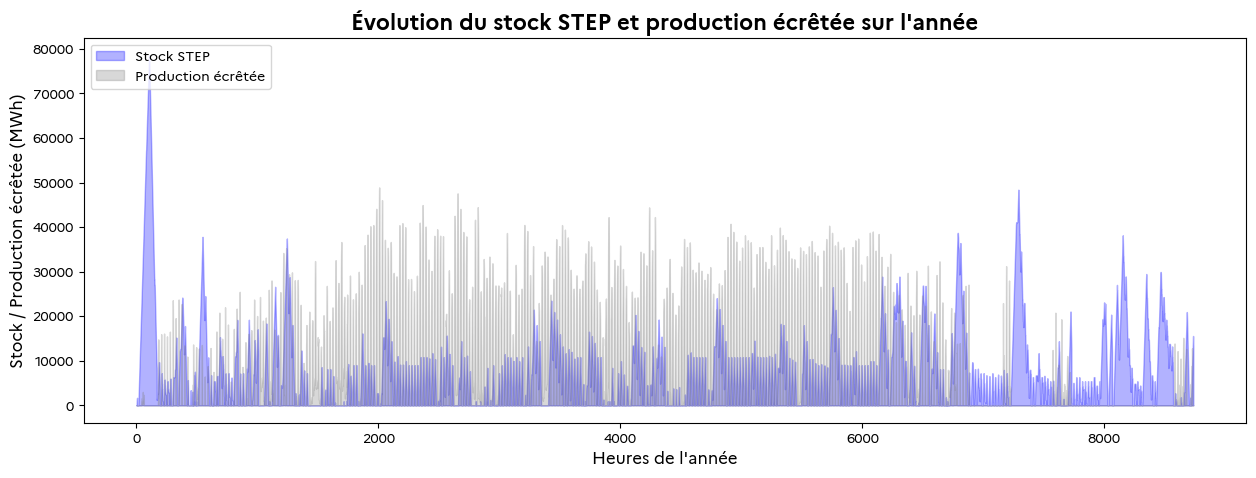

In [ ]:
import matplotlib.pyplot as plt

time = df_global.index  # index de 0 à 8735

fig, ax1 = plt.subplots(figsize=(15,5))

# Axe principal : Stock STEP et Batterie + Production écrêtée (Exces)
ax1.fill_between(time, 0, df_global["STEP_stock"], color='blue', alpha=0.3, label="Stock STEP")
ax1.fill_between(time, 0, df_global["Exces"], color='gray', alpha=0.3, label="Production écrêtée")
ax1.set_xlabel("Heures de l'année")
ax1.set_ylabel("Stock / Production écrêtée (MWh)")
ax1.legend(loc='upper left')

# # Axe secondaire : Charge et décharge
# ax2 = ax1.twinx()
# #ax2.plot(time, -df_global["STEP_charge"], color='green', linewidth=1, label="Charge STEP")
# # ax2.plot(time, df_global["STEP_discharge"], color='red', linewidth=1, label="Décharge STEP")

# ax2.set_ylabel("Puissance de charge/décharge (MW)")
# ax2.legend(loc='upper right')

plt.title("Évolution du stock STEP et production écrêtée sur l'année")
plt.show()


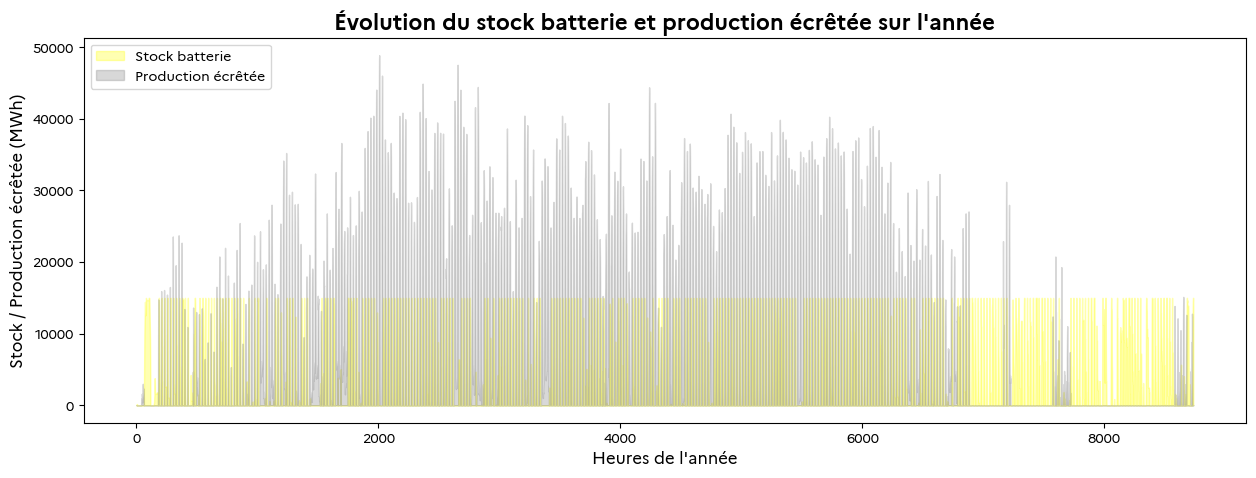

In [ ]:
fig, ax1 = plt.subplots(figsize=(15,5))

# Axe principal : Stock STEP et Batterie + Production écrêtée (Exces)
ax1.fill_between(time, 0, df_global["Battery_stock"], color='yellow', alpha=0.3, label="Stock batterie")
ax1.fill_between(time, 0, df_global["Exces"], color='gray', alpha=0.3, label="Production écrêtée")
ax1.set_xlabel("Heures de l'année")
ax1.set_ylabel("Stock / Production écrêtée (MWh)")
ax1.legend(loc='upper left')

# # Axe secondaire : Charge et décharge
# ax2 = ax1.twinx()
# #ax2.plot(time, -df_global["STEP_charge"], color='green', linewidth=1, label="Charge STEP")
# # ax2.plot(time, df_global["STEP_discharge"], color='red', linewidth=1, label="Décharge STEP")

# ax2.set_ylabel("Puissance de charge/décharge (MW)")
# ax2.legend(loc='upper right')

plt.title("Évolution du stock batterie et production écrêtée sur l'année")
plt.show()

## **4. Hydraulique**

**4.1 Variante modélisation stock hydro lac**

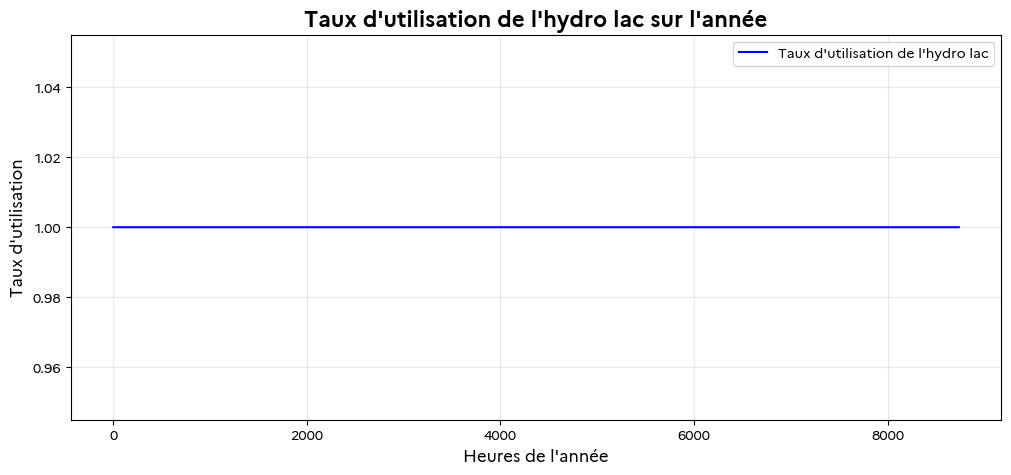

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df_global.index, df_global["Hydro_lac_utilization_rate"], color='blue', label="Taux d'utilisation de l'hydro lac")
plt.xlabel("Heures de l'année")
plt.ylabel("Taux d'utilisation")
plt.title("Taux d'utilisation de l'hydro lac sur l'année")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## **5. Centrales H2**

In [ ]:

r_CCG_H2 = 0.6 #idem que les CCG_gaz
r_TAC_H2 = 0.4 #idem que les TAC_gaz
r_électrolyse = 0.7

print("Production annuelle écretée", df_global["Exces"].sum(), "\n")
print("Production électricité à partir des centrales H2 annuelle", df_global["H2_CCG"].sum() + df_global["H2_TAC"].sum(), "\n")
print("Quantité hydrogène annuelle pour production électricité", df_global["H2_CCG"].sum()*r_CCG_H2 + df_global["H2_TAC"].sum()*r_TAC_H2, "\n")
print("Taux d'utilisation prod écrêtée pour prod H2", (df_global["H2_CCG"].sum()/(r_électrolyse*r_CCG_H2) + df_global["H2_TAC"].sum()/(r_électrolyse*r_TAC_H2)) / df_global["Exces"].sum() * 100, "%\n")



Production annuelle écretée 55696594.519999996 

Production électricité à partir des centrales H2 annuelle 5844969.59 

Quantité hydrogène annuelle pour production électricité 3461142.0779999997 

Taux d'utilisation prod écrêtée pour prod H2 25.476332257792194 %



Text(0.5, 1.0, "Production d'électricité à partir de l'hydrogène sur l'année")

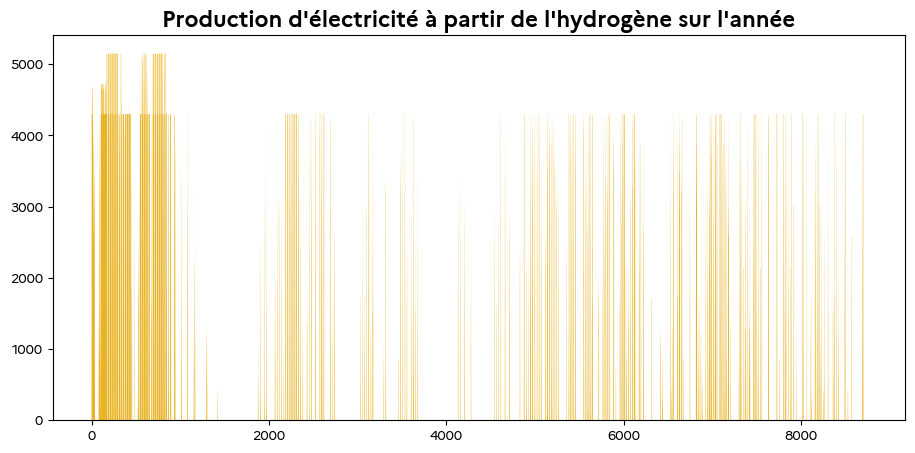

In [ ]:
plt.figure(figsize=(11,5))

# Palette réduite
palette2 = {
    "H2_CCG": "#e4a701",
    "H2_TAC": "#f0c040"
}

# Colonnes production (positives)
prod_cols2 = [
    'H2_CCG',
    'H2_TAC'
]

# Pas de charges
charge_cols = []

plt.stackplot(
    df_global.index,
    [df_global[c] for c in prod_cols2],
    colors=[palette2[c] for c in prod_cols2],
    labels=prod_cols2,
    alpha=0.85
)
plt.title("Production d'électricité à partir de l'hydrogène sur l'année")

## **6. Défaillance**

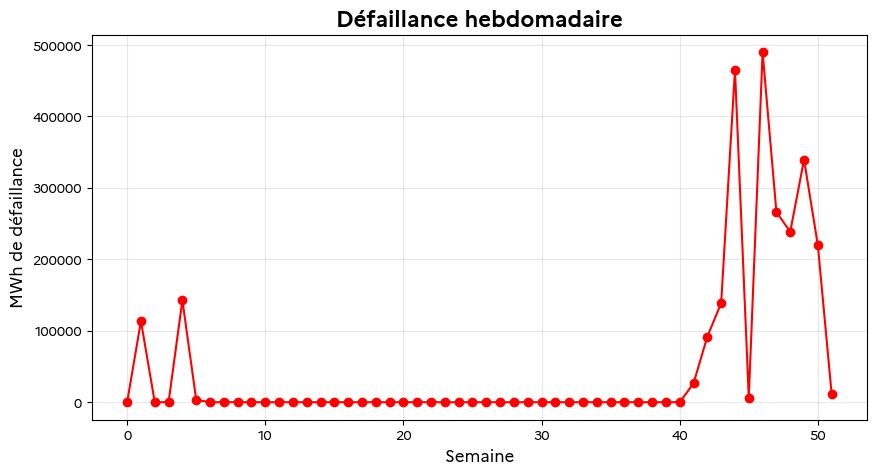

In [ ]:
defaillance = df_global["Defailance"]
weeks = np.arange(len(defaillance)) // (7*24)
weekly_defaillance = [defaillance[weeks == w].sum() for w in np.unique(weeks)]

plt.figure(figsize=(10,5))
plt.plot(weekly_defaillance, marker='o', color='red')
plt.title("Défaillance hebdomadaire")
plt.xlabel("Semaine")
plt.ylabel("MWh de défaillance")
plt.grid(alpha=0.3)
plt.show()

## **7. Production écrêtée à l'année**

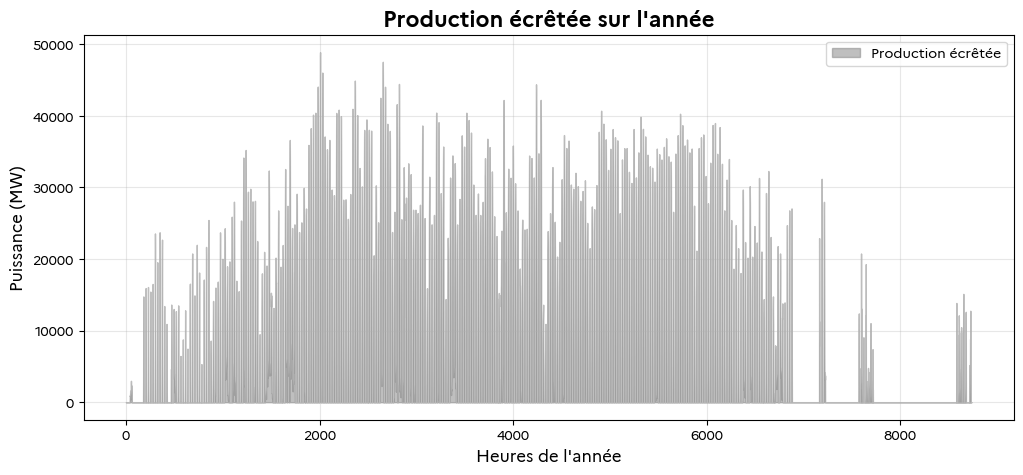

In [ ]:


plt.figure(figsize=(12,5))
plt.fill_between(df_global.index, 0, df_global["Exces"], color='grey', alpha=0.5, label="Production écrêtée")
plt.xlabel("Heures de l'année")
plt.ylabel("Puissance (MW)")
plt.title("Production écrêtée sur l'année")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## **6. Evolution des capacités dans l'optimisation**

In [ ]:
weeks = evolution_parc["semaine"]
onshore = evolution_parc["capacites_MW"]["onshore"]
offshore = evolution_parc["capacites_MW"]["offshore"]
solar = evolution_parc["capacites_MW"]["solar"]
battery = evolution_parc["capacites_MW"]["battery"]
electrolyzer = evolution_parc["capacites_MW"]["electrolyzer"]


ccg = [val * 430.0 for val in evolution_parc["H2"]["CCG"].get("nombre_installees", [0])]
tac = [val * 85.0 for val in evolution_parc["H2"]["TAC"].get("nombre_installees", [0])] 

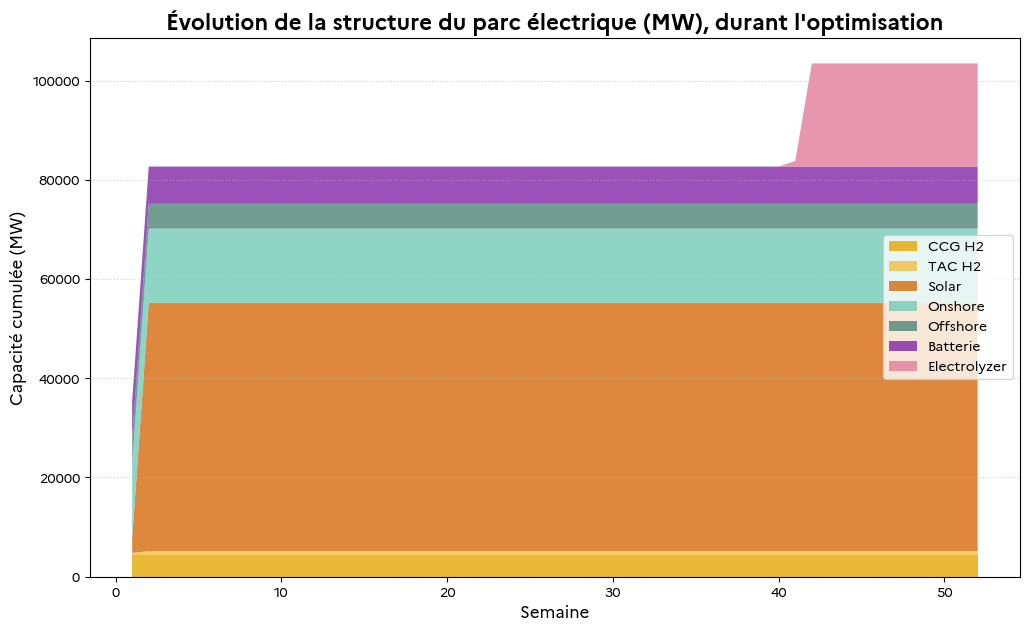

In [ ]:
plt.figure(figsize=(12, 7))

# On empile les données
plt.stackplot(weeks, ccg, tac, solar,onshore, offshore, battery, electrolyzer,
              labels=["CCG H2", "TAC H2", "Solar", "Onshore", "Offshore", "Batterie", "Electrolyzer"],
              colors=[palette["H2_CCG"], palette["H2_TAC"], palette["Solar"], palette["Onshore"], palette["Offshore"], palette["Battery"], palette["Electrolyse"]],
              alpha=0.8)

plt.title("Évolution de la structure du parc électrique (MW), durant l'optimisation")
plt.ylabel("Capacité cumulée (MW)")
plt.xlabel("Semaine")
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend()

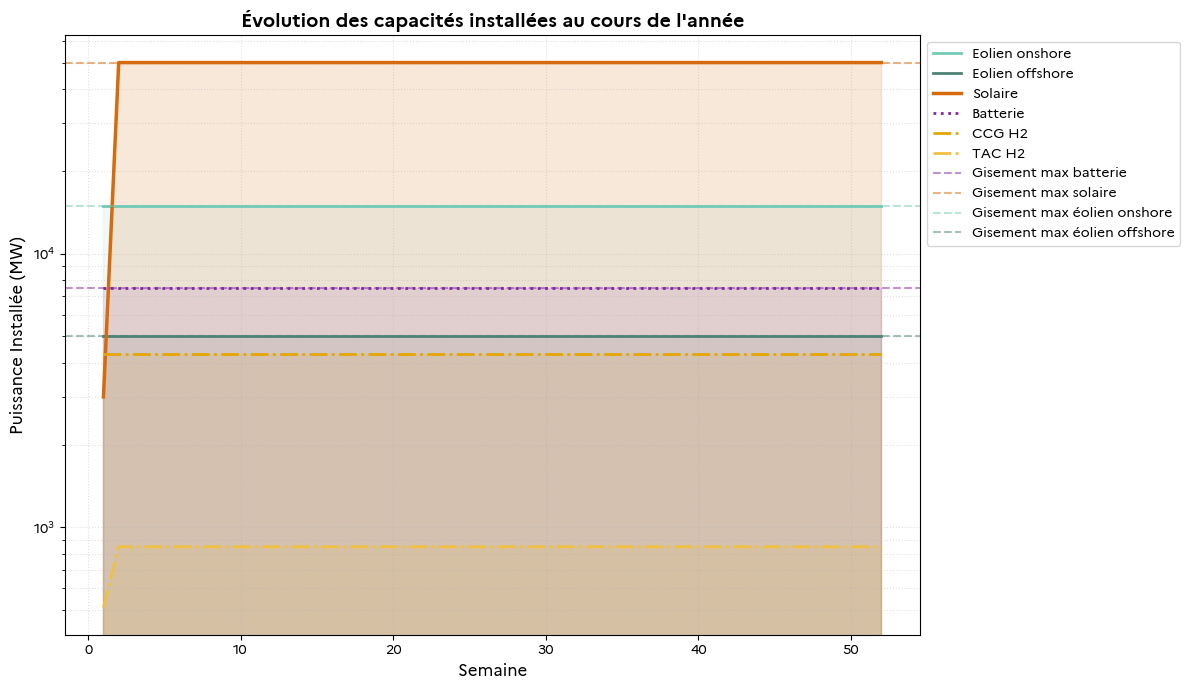

In [ ]:
import matplotlib.pyplot as plt

# --- 1. Préparation des données (Identique à votre code) ---
weeks = evolution_parc["semaine"]
onshore = evolution_parc["capacites_MW"]["onshore"]
offshore = evolution_parc["capacites_MW"]["offshore"]
solar = evolution_parc["capacites_MW"]["solar"]
battery = evolution_parc["capacites_MW"]["battery"]

# Vos listes calculées précédemment
ccg = [val * 430.0 for val in evolution_parc["H2"]["CCG"].get("nombre_installees", [0])]
tac = [val * 85.0 for val in evolution_parc["H2"]["TAC"].get("nombre_installees", [0])]

# Palette de couleurs (si vous n'en avez pas, j'en crée une par défaut)
# palette = {...}

# --- 2. Création de la figure ---
plt.figure(figsize=(12, 7))

# --- 3. Tracé des Courbes + Ajout du STYLE "Fill Between" ---

# Éolien Onshore
plt.plot(weeks, onshore, label="Eolien onshore", color=palette["Onshore"], linewidth=2)
plt.fill_between(weeks, onshore, color=palette["Onshore"], alpha=0.1) # Remplissage léger

# Éolien Offshore
plt.plot(weeks, offshore, label="Eolien offshore", color=palette["Offshore"], linewidth=2)
plt.fill_between(weeks, offshore, color=palette["Offshore"], alpha=0.1)

# Solaire
plt.plot(weeks, solar, label="Solaire", color=palette["Solar"], linewidth=2.5)
plt.fill_between(weeks, solar, color=palette["Solar"], alpha=0.15) # Un peu plus opaque pour le Solaire

# Batterie
plt.plot(weeks, battery, label="Batterie", color=palette["Battery"], linewidth=2, linestyle=':')
plt.fill_between(weeks, battery, color=palette["Battery"], alpha=0.1)

# CCG H2
plt.plot(weeks, ccg, label="CCG H2", color=palette["H2_CCG"], linewidth=2, linestyle='-.')
plt.fill_between(weeks, ccg, color=palette["H2_CCG"], alpha=0.1)

# TAC H2
plt.plot(weeks, tac, label="TAC H2", color=palette["H2_TAC"], linewidth=2, linestyle='-.')
plt.fill_between(weeks, tac, color=palette["H2_TAC"], alpha=0.1)


# --- 4. Cosmétique et Gisements (Identique à votre code) ---
plt.title("Évolution des capacités installées au cours de l'année", fontsize=14, fontweight='bold')

plt.axhline(y=7500, color=palette["Battery"], linestyle='--', alpha=0.5, label="Gisement max batterie")
plt.axhline(y=50000, color=palette["Solar"], linestyle='--', alpha=0.5, label="Gisement max solaire")
plt.axhline(y=15000, color=palette["Onshore"], linestyle='--', alpha=0.5, label="Gisement max éolien onshore")
plt.axhline(y=5000, color=palette["Offshore"], linestyle='--', alpha=0.5, label="Gisement max éolien offshore")

plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Sortir la légende pour ne pas cacher les gisements

plt.yscale("log")
plt.xlabel("Semaine", fontsize=12)
plt.ylabel("Puissance Installée (MW)", fontsize=12)
plt.grid(True, which="both", linestyle=':', alpha=0.4) # Grille adaptée au log

plt.tight_layout() # Évite que la légende ne soit coupée
plt.show()

### **7. H2**

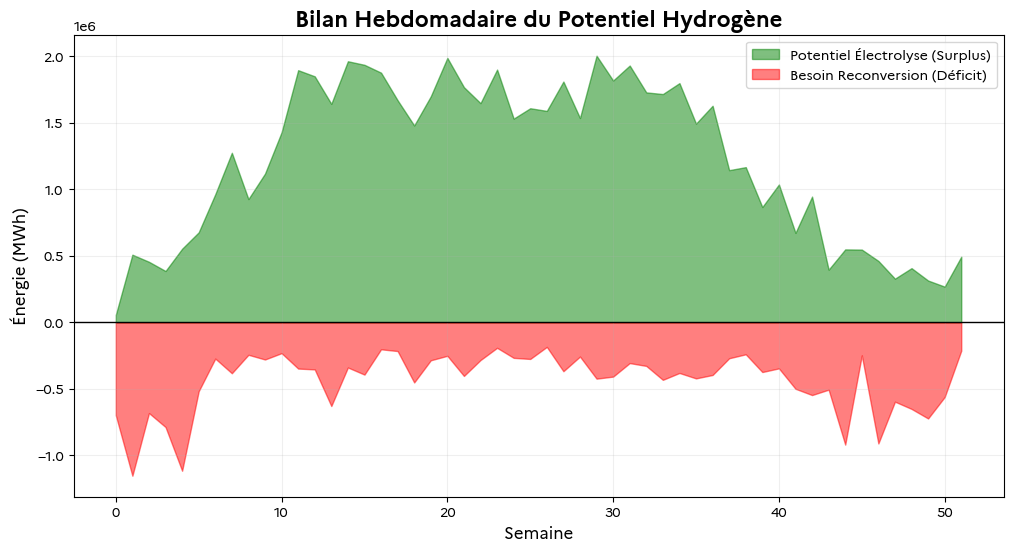

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Calcul des Flux Nets (au pas horaire pour éviter de lisser l'intermittence) ---
# On calcule la production ENR totale par heure
df_global['Total_ENR'] = df_global[['Solar', 'Offshore', 'Onshore']].sum(axis=1)

# On calcule l'écart (Surplus ou Déficit)
df_global['Net_Balance'] = df_global['Total_ENR'] - df_global['Load']

# --- 2. Identification des Potentiels H2 ---
# Potentiel de production : Ce qu'on peut stocker (Surplus ENR)
df_global['H2_Prod_Potential'] = df_global['Net_Balance'].clip(lower=0)

# Besoin de déstockage : Ce qu'on doit fournir (Déficit ENR)
df_global['H2_Generation_Need'] = (-df_global['Net_Balance']).clip(lower=0)

# --- 3. Agrégation Hebdomadaire ---
weekly_h2 = df_global[['H2_Prod_Potential', 'H2_Generation_Need', 'Load']].groupby(df_global.index // (7*24)).sum()

# --- 4. Indicateur d'Agnosticisme (H2-Index) ---
# Ratio : Surplus disponible / Besoin réel. 
# Si > 1, la semaine est potentiellement autonome en H2.
weekly_h2['H2_Autonomy_Ratio'] = weekly_h2['H2_Prod_Potential'] / weekly_h2['H2_Generation_Need']

plt.figure(figsize=(12, 6))
plt.fill_between(weekly_h2.index, weekly_h2['H2_Prod_Potential'], color='green', alpha=0.5, label='Potentiel Électrolyse (Surplus)')
plt.fill_between(weekly_h2.index, -weekly_h2['H2_Generation_Need'], color='red', alpha=0.5, label='Besoin Reconversion (Déficit)')
plt.axhline(0, color='black', lw=1)
plt.title("Bilan Hebdomadaire du Potentiel Hydrogène")
plt.xlabel("Semaine")
plt.ylabel("Énergie (MWh)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))

if "H2_stock" in df_global.columns:
    plt.plot(df_global.index, df_global['H2_stock'], color='blue', label='Stock d\'H2 (MWh)')
    plt.title("Évolution du stock d'hydrogène au cours de l'année")
    plt.xlabel("Heure")
    plt.ylabel("Stock d'hydrogène (MWh)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

<Figure size 1200x600 with 0 Axes>

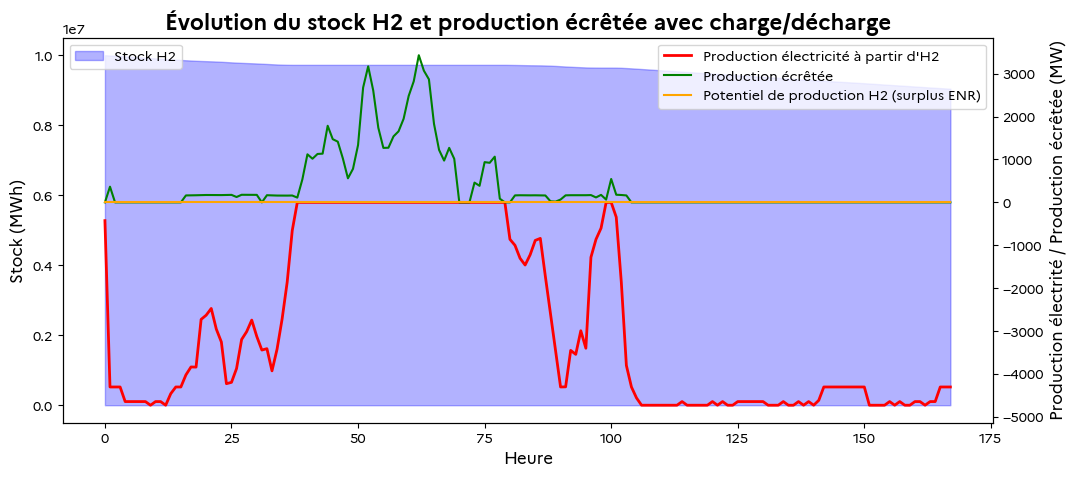

In [ ]:
fig, ax1 = plt.subplots(figsize=(12,5))

time = df.index

# Axe principal : Stock STEP et production écrêtée
ax1.fill_between(time, 0, df["H2_Stock"], color='blue', alpha=0.3, label="Stock H2")
# ax1.fill_between(time, 0, df["Ecret"], color='gray', alpha=0.3, label="Production écrêtée")
ax1.set_xlabel("Heure")
ax1.set_ylabel("Stock (MWh)")
ax1.legend(loc='upper left')

# Axe secondaire : Charge et décharge
ax2 = ax1.twinx()
ax2.plot(time, -df["H2_CCG"]-df["H2_TAC"], color='red', linewidth=2, label="Production électricité à partir d'H2")
ax2.plot(time, df["Ecret"], color='green', label="Production écrêtée")
ax2.plot(time, df["Electrolyse"], color='orange', label="Potentiel de production H2 (surplus ENR)")
# ax2.plot(time, df["H2_discharge"], color='red', linewidth=2, label="Décharge H2")
ax2.set_ylabel("Production électrité / Production écrêtée (MW)")
ax2.legend(loc='upper right')

plt.title("Évolution du stock H2 et production écrêtée avec charge/décharge")
plt.show()

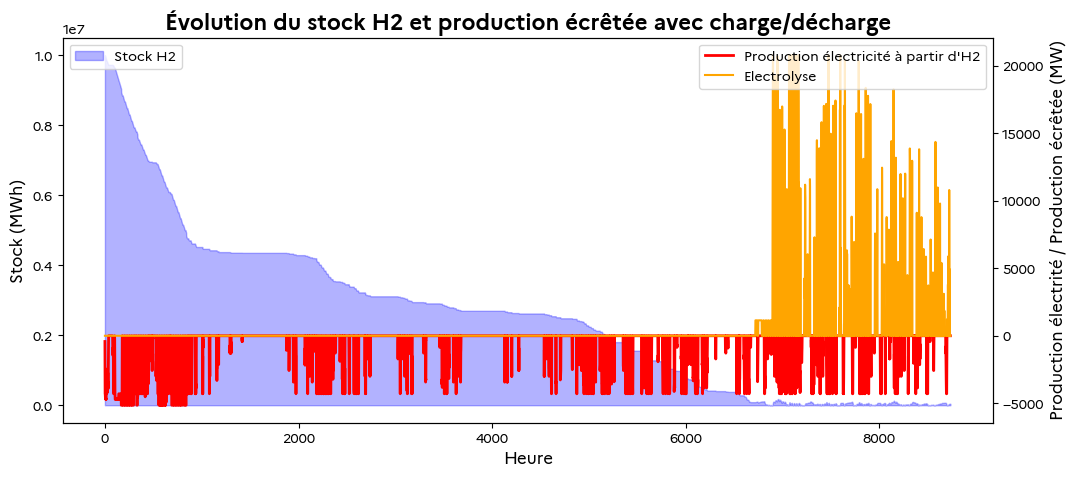

In [ ]:
fig, ax1 = plt.subplots(figsize=(12,5))

time = df_global.index

# Axe principal : Stock STEP et production écrêtée
ax1.fill_between(time, 0, df_global["H2_Stock"], color='blue', alpha=0.3, label="Stock H2")
# ax1.fill_between(time, 0, df_global["Ecret"], color='gray', alpha=0.3, label="Production écrêtée")
ax1.set_xlabel("Heure")
ax1.set_ylabel("Stock (MWh)")
ax1.legend(loc='upper left')

# Axe secondaire : Charge et décharge
ax2 = ax1.twinx()
ax2.plot(time, -df_global["H2_CCG"]-df_global["H2_TAC"], color='red', linewidth=2, label="Production électricité à partir d'H2")
ax2.plot(time, df_global["Electrolyse"], color='orange', label="Electrolyse")
# ax2.plot(time, df_global["H2_discharge"], color='red', linewidth=2, label="Décharge H2")
ax2.set_ylabel("Production électrité / Production écrêtée (MW)")
ax2.legend(loc='upper right')

plt.title("Évolution du stock H2 et production écrêtée avec charge/décharge")
plt.show()